# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

Exception ignored in: <function _xla_gc_callback at 0x782e8a3bf2e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


In [2]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [3]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.layer1 = DenseLayer(num_features, n_hidden_1)
        self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)
        self.output = DenseLayer(n_hidden_2, num_classes)

    def __call__(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return self.output(x, activation=1)

In [9]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    predicted = tf.argmax(y_pred, axis=1)
    correct = tf.equal(predicted, tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct, tf.float32))

In [10]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):

    optimizer = tf.optimizers.SGD(learning_rate)

    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)
        trainable_variables = [
            neural_net.layer1.w,
            neural_net.layer1.b,
            neural_net.layer2.w,
            neural_net.layer2.b,
            neural_net.output.w,
            neural_net.output.b
        ]

        gradients = g.gradient(loss, trainable_variables)

        optimizer.apply_gradients(zip(gradients, trainable_variables))

In [11]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    train(neural_net, batch_x, batch_y)
    if step % display_step == 0:
        pred = neural_net(batch_x)
        loss_value = cross_entropy(pred, batch_y)
        acc_value = accuracy(pred, batch_y)
        loss_history.append(loss_value.numpy())
        accuracy_history.append(acc_value.numpy())
        print(f"Step {step}, "f"Loss = {loss_value:.4f}, "f"Accuracy = {acc_value:.4f}")


Step 100, Loss = 401.0253, Accuracy = 0.6680
Step 200, Loss = 222.5648, Accuracy = 0.7656
Step 300, Loss = 191.8962, Accuracy = 0.8125
Step 400, Loss = 152.4900, Accuracy = 0.8320
Step 500, Loss = 147.0831, Accuracy = 0.8086
Step 600, Loss = 124.0327, Accuracy = 0.8594
Step 700, Loss = 104.5243, Accuracy = 0.8555
Step 800, Loss = 101.8453, Accuracy = 0.9023
Step 900, Loss = 77.7525, Accuracy = 0.8867
Step 1000, Loss = 90.4923, Accuracy = 0.8906
Step 1100, Loss = 126.3752, Accuracy = 0.8477
Step 1200, Loss = 90.0572, Accuracy = 0.8945
Step 1300, Loss = 75.9192, Accuracy = 0.9141
Step 1400, Loss = 55.4806, Accuracy = 0.9297
Step 1500, Loss = 78.9889, Accuracy = 0.9141
Step 1600, Loss = 97.7979, Accuracy = 0.8789
Step 1700, Loss = 92.7269, Accuracy = 0.9023
Step 1800, Loss = 64.8214, Accuracy = 0.9219
Step 1900, Loss = 91.9709, Accuracy = 0.9023
Step 2000, Loss = 64.9319, Accuracy = 0.9180
Step 2100, Loss = 86.5609, Accuracy = 0.9180
Step 2200, Loss = 62.2398, Accuracy = 0.9258
Step 2300,

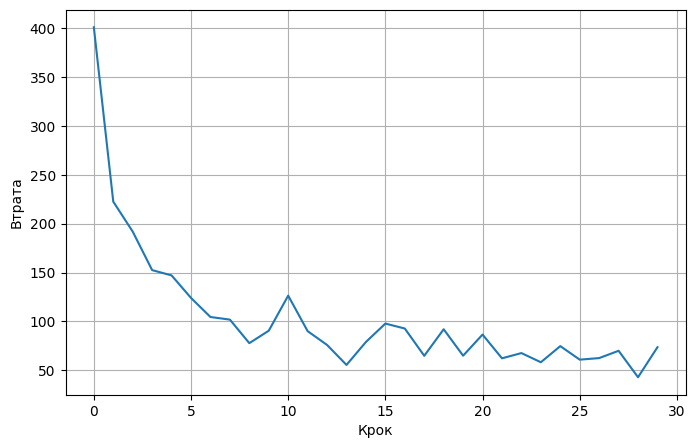

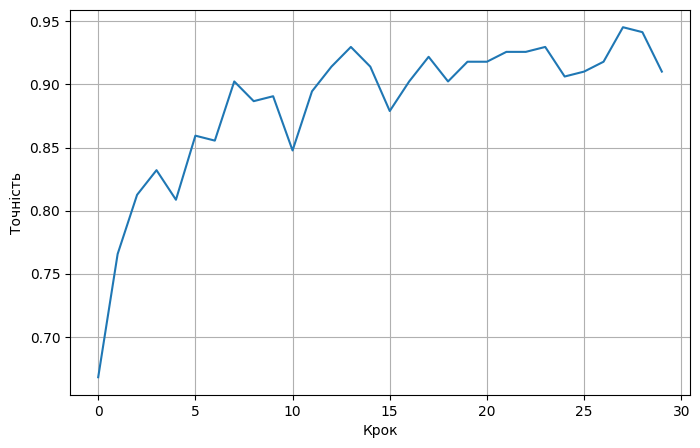

In [13]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Крок")
plt.ylabel("Втрата")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(accuracy_history)
plt.xlabel("Крок")
plt.ylabel("Точність")
plt.grid()
plt.show()

In [18]:
from sklearn.metrics import classification_report
pred = neural_net(x_test)
test_acc = accuracy(pred, y_test)
print("Точність тесту:", test_acc.numpy())
predicted_classes = tf.argmax(pred, axis=1).numpy()
print(classification_report(y_test,predicted_classes,digits=4))

Точність тесту: 0.9004
              precision    recall  f1-score   support

           0     0.9439    0.9612    0.9525       980
           1     0.9761    0.9727    0.9744      1135
           2     0.8774    0.8944    0.8858      1032
           3     0.8705    0.8851    0.8778      1010
           4     0.9101    0.8870    0.8984       982
           5     0.8700    0.8251    0.8470       892
           6     0.9203    0.9280    0.9241       958
           7     0.9061    0.9105    0.9083      1028
           8     0.8603    0.8347    0.8473       974
           9     0.8574    0.8880    0.8724      1009

    accuracy                         0.9004     10000
   macro avg     0.8992    0.8987    0.8988     10000
weighted avg     0.9004    0.9004    0.9002     10000



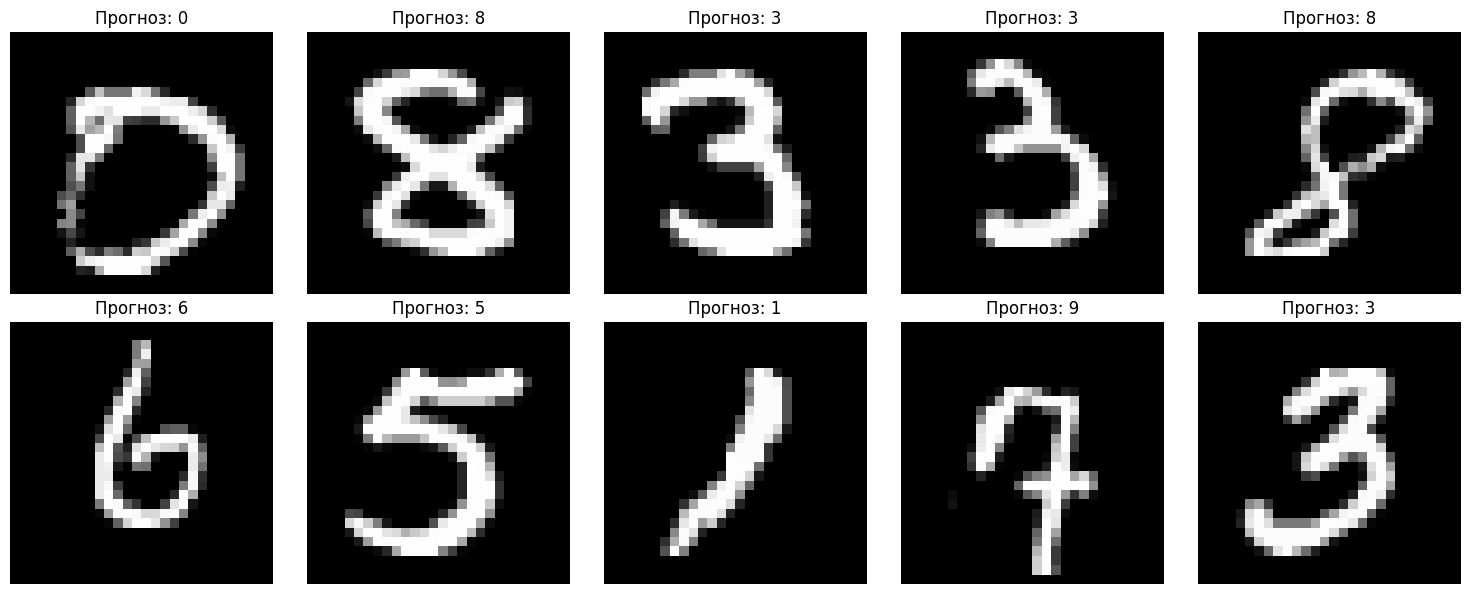

In [15]:
indices = random.sample(range(len(x_test)), 10)
plt.figure(figsize=(15,6))
for i, idx in enumerate(indices):
    image = x_test[idx].reshape(28,28)
    prediction = neural_net(tf.expand_dims(x_test[idx], axis=0))
    digit = tf.argmax(prediction, axis=1).numpy()[0]
    plt.subplot(2,5,i+1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Прогноз: {digit}")
    plt.axis("off")
plt.tight_layout()
plt.show()



Після навчання нейронна мережа досягла високої точності класифікації на тестовій вибірці. Графік функції втрат показує поступове її зменшення а графік точності зростання під час навчання хоч і з певними розгалуженями. При перевірці на випадкових зображеннях мережа правильно розпізнала більшість цифр. Помилки виникають лише у випадках коли цифри дуже схожі між собою наприклад як вийшло з 7 і 9